In [53]:
!pip install -r requirements.txt

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import shap
from statsmodels.stats.proportion import proportions_ztest

In [5]:
df = pd.read_csv("lp_sessions.csv")

In [7]:
display(df)

,session_id,timestamp,traffic_source,campaign_id,device_type,landing_page_variant,geo_region,returning_visitor,session_duration_sec,scroll_depth_pct,num_clicks,sections_viewed,time_to_first_scroll_sec,form_started,form_field_interactions,converted,appointment_set
0,s_672811,2026-02-22 12:55:14,google,g_camp_0011,tablet,A,South,0,13.7,16.4,3,0,2.77,0,0,0,NaN
1,s_613680,2026-02-26 22:48:48,facebook,fb_camp_0002,mobile,B,South,0,7.8,32.0,3,1,5.51,0,0,0,NaN
2,s_311500,2026-02-16 18:53:35,facebook,fb_camp_0001,desktop,A,West,0,6.9,16.8,3,3,4.74,0,0,0,NaN
3,s_094737,2026-03-14 02:34:48,facebook,fb_camp_0002,mobile,A,South,0,68.7,14.3,1,2,10.54,0,0,0,NaN
4,s_118424,2026-02-25 16:31:56,google,g_camp_0011,desktop,A,South,0,62.0,26.4,10,4,2.75,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20035,s_385370,2026-03-15 13:04:25,google,g_camp_0011,desktop,A,Midwest,1,47.8,51.2,6,5,4.61,0,0,0,NaN
20036,s_850287,2026-02-19 18:46:17,facebook,fb_camp_0001,mobile,A,West,0,2.5,0.0,0,0,20.18,0,0,0,NaN
20037,s_517624,2026-02-03 13:39:57,facebook,fb_camp_0001,desktop,A,West,0,11.1,51.4,0,4,7.17,0,0,0,NaN
20038,s_172693,2026-03-15 14:40:31,facebook,fb_camp_0003,mobile,B,West,0,18.0,32.7,3,2,4.48,0,0,0,NaN


In [8]:
df.describe()

,returning_visitor,session_duration_sec,scroll_depth_pct,num_clicks,sections_viewed,time_to_first_scroll_sec,form_started,form_field_interactions,converted,appointment_set
count,20040.000000,20040.000000,19636.000000,20040.000000,20040.000000,19740.000000,20040.000000,20040.000000,20040.000000,880.000000
mean,0.182585,46.279082,38.744597,5.646058,2.973752,5.108659,0.179641,0.786727,0.043912,0.247727
std,0.386335,54.374801,26.090519,10.271310,1.939684,3.562020,0.383897,2.071029,0.204905,0.431938
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.210000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,14.700000,17.600000,2.000000,1.000000,2.710000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.200000,37.900000,3.000000,3.000000,4.285000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,56.700000,57.300000,6.000000,4.000000,6.490000,0.000000,0.000000,0.000000,0.000000
max,1.000000,880.600000,100.000000,79.000000,10.000000,60.000000,1.000000,12.000000,1.000000,1.000000


In [13]:
df.dtypes

session_id                      str
timestamp                       str
traffic_source                  str
campaign_id                     str
device_type                     str
landing_page_variant            str
geo_region                      str
returning_visitor             int64
session_duration_sec        float64
scroll_depth_pct            float64
num_clicks                    int64
sections_viewed               int64
time_to_first_scroll_sec    float64
form_started                  int64
form_field_interactions       int64
converted                      bool
appointment_set             float64
dtype: object

In [6]:
df["converted"] = df["converted"].astype(bool)

In [19]:
df[df['scroll_depth_pct'].isna() & df['time_to_first_scroll_sec'].isna()].shape[0]

6

In [17]:
df[df['scroll_depth_pct'].isna()]['session_duration_sec'].describe()

count    404.000000
mean      49.349257
std       63.255251
min        0.000000
25%       14.575000
50%       27.000000
75%       57.450000
max      465.400000
Name: session_duration_sec, dtype: float64

In [18]:
df[df['time_to_first_scroll_sec'].isna()]['session_duration_sec'].describe()

count    300.000000
mean      42.895000
std       41.216702
min        0.000000
25%       13.800000
50%       28.300000
75%       57.800000
max      229.100000
Name: session_duration_sec, dtype: float64

In [7]:
df['scroll_depth_missing'] = df['scroll_depth_pct'].isna().astype(int)
df['time_to_scroll_missing'] = df['time_to_first_scroll_sec'].isna().astype(int)

In [8]:
df['scroll_depth_pct'] = df['scroll_depth_pct'].fillna(df['scroll_depth_pct'].median())
df['time_to_first_scroll_sec'] = df['time_to_first_scroll_sec'].fillna(df['time_to_first_scroll_sec'].median())

In [21]:
df[(df['form_started']==0) & (df['form_field_interactions']>0)].shape[0]

0

In [20]:
df[(df['converted']==1) & (df['form_started']==0)].shape[0]

0

In [9]:
categorical_cols = ['traffic_source', 'device_type', 'geo_region', 'landing_page_variant','campaign_id']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [55]:
display(df)

,session_id,timestamp,returning_visitor,session_duration_sec,scroll_depth_pct,num_clicks,sections_viewed,time_to_first_scroll_sec,form_started,form_field_interactions,...,geo_region_Northeast,geo_region_South,geo_region_West,landing_page_variant_B,campaign_id_fb_camp_0002,campaign_id_fb_camp_0003,campaign_id_fb_camp_0007,campaign_id_g_camp_0011,campaign_id_g_camp_0012,campaign_id_g_camp_0013
0,s_672811,2026-02-22 12:55:14,0,13.7,16.4,3,0,2.77,0,0,...,False,True,False,False,False,False,False,True,False,False
1,s_613680,2026-02-26 22:48:48,0,7.8,32.0,3,1,5.51,0,0,...,False,True,False,True,True,False,False,False,False,False
2,s_311500,2026-02-16 18:53:35,0,6.9,16.8,3,3,4.74,0,0,...,False,False,True,False,False,False,False,False,False,False
3,s_094737,2026-03-14 02:34:48,0,68.7,14.3,1,2,10.54,0,0,...,False,True,False,False,True,False,False,False,False,False
4,s_118424,2026-02-25 16:31:56,0,62.0,26.4,10,4,2.75,0,0,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20035,s_385370,2026-03-15 13:04:25,1,47.8,51.2,6,5,4.61,0,0,...,False,False,False,False,False,False,False,True,False,False
20036,s_850287,2026-02-19 18:46:17,0,2.5,0.0,0,0,20.18,0,0,...,False,False,True,False,False,False,False,False,False,False
20037,s_517624,2026-02-03 13:39:57,0,11.1,51.4,0,4,7.17,0,0,...,False,False,True,False,False,False,False,False,False,False
20038,s_172693,2026-03-15 14:40:31,0,18.0,32.7,3,2,4.48,0,0,...,False,False,True,True,False,True,False,False,False,False


In [16]:
df.describe()

,returning_visitor,session_duration_sec,scroll_depth_pct,num_clicks,sections_viewed,time_to_first_scroll_sec,form_started,form_field_interactions,appointment_set,scroll_depth_missing,time_to_scroll_missing
count,20040.000000,20040.000000,20040.000000,20040.000000,20040.000000,20040.000000,20040.000000,20040.000000,880.000000,20040.00000,20040.000000
mean,0.182585,46.279082,38.727570,5.646058,2.973752,5.096329,0.179641,0.786727,0.247727,0.02016,0.014970
std,0.386335,54.374801,25.826451,10.271310,1.939684,3.536671,0.383897,2.071029,0.431938,0.14055,0.121436
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.210000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,14.700000,18.200000,2.000000,1.000000,2.730000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,0.000000,29.200000,37.900000,3.000000,3.000000,4.285000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,0.000000,56.700000,56.900000,6.000000,4.000000,6.450000,0.000000,0.000000,0.000000,0.00000,0.000000
max,1.000000,880.600000,100.000000,79.000000,10.000000,60.000000,1.000000,12.000000,1.000000,1.00000,1.000000


In [40]:
df.isna().sum()

session_id                      0
timestamp                       0
returning_visitor               0
session_duration_sec            0
scroll_depth_pct                0
num_clicks                      0
sections_viewed                 0
time_to_first_scroll_sec        0
form_started                    0
form_field_interactions         0
converted                       0
appointment_set             19160
scroll_depth_missing            0
time_to_scroll_missing          0
traffic_source_google           0
device_type_mobile              0
device_type_tablet              0
geo_region_Northeast            0
geo_region_South                0
geo_region_West                 0
landing_page_variant_B          0
campaign_id_fb_camp_0002        0
campaign_id_fb_camp_0003        0
campaign_id_fb_camp_0007        0
campaign_id_g_camp_0011         0
campaign_id_g_camp_0012         0
campaign_id_g_camp_0013         0
dtype: int64

In [50]:
df.groupby('converted')['form_started'].mean()

converted
False    0.141962
True     1.000000
Name: form_started, dtype: float64

In [10]:
drop_cols = ['session_id', 'timestamp', 'form_started', 'form_field_interactions', 
             'appointment_set', 'converted']

feature_cols = [c for c in df.columns if c not in drop_cols]
target_corr = df[feature_cols].corrwith(df['converted']).sort_values(key=abs, ascending=False)
display(target_corr)

scroll_depth_pct            0.266355
sections_viewed             0.265942
session_duration_sec        0.239338
traffic_source_google       0.188459
device_type_mobile         -0.121889
time_to_first_scroll_sec   -0.121050
campaign_id_g_camp_0011     0.095900
campaign_id_g_camp_0012     0.092212
campaign_id_g_camp_0013     0.083249
campaign_id_fb_camp_0002   -0.077087
campaign_id_fb_camp_0003   -0.053412
campaign_id_fb_camp_0007   -0.048282
num_clicks                  0.036360
returning_visitor           0.022899
device_type_tablet         -0.021426
geo_region_South           -0.011551
geo_region_Northeast        0.010036
geo_region_West             0.007550
landing_page_variant_B     -0.006228
time_to_scroll_missing     -0.004359
scroll_depth_missing       -0.001283
dtype: float64

In [ ]:
# Training

In [11]:
X = df[feature_cols]
y = df['converted']

print(X.shape, y.mean())

(20040, 21) 0.043912175648702596


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(f"train: {len(y_train)}, pos rate {y_train.mean():.4f}")
print(f"val:   {len(y_val)}, pos rate {y_val.mean():.4f}")
print(f"test:  {len(y_test)}, pos rate {y_test.mean():.4f}")

train: 12825, pos rate 0.0439
val:   3207, pos rate 0.0440
test:  4008, pos rate 0.0439


In [51]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 21.78


In [13]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

scale_pos_weight: 21.78
[0]	validation_0-aucpr:0.23763
[50]	validation_0-aucpr:0.28774
[64]	validation_0-aucpr:0.29125


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
print("Best iteration:", model.best_iteration)
print("Best score:", model.best_score)

Best iteration: 34
Best score: 0.2921482259024078


In [52]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_label = (y_pred_proba > 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

ROC-AUC: 0.8853
PR-AUC:  0.3070


In [16]:
model.save_model('intent_propensity_xgb.json')

In [17]:
print("\nAt default 0.5 threshold")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_label):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_label):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_label):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_label):.4f}")

print(confusion_matrix(y_test, y_pred_label))
print("\n", classification_report(y_test, y_pred_label))


At default 0.5 threshold
Accuracy:  0.8141
Precision: 0.1665
Recall:    0.8068
F1:        0.2760
[[3121  711]
 [  34  142]]

               precision    recall  f1-score   support

       False       0.99      0.81      0.89      3832
        True       0.17      0.81      0.28       176

    accuracy                           0.81      4008
   macro avg       0.58      0.81      0.58      4008
weighted avg       0.95      0.81      0.87      4008



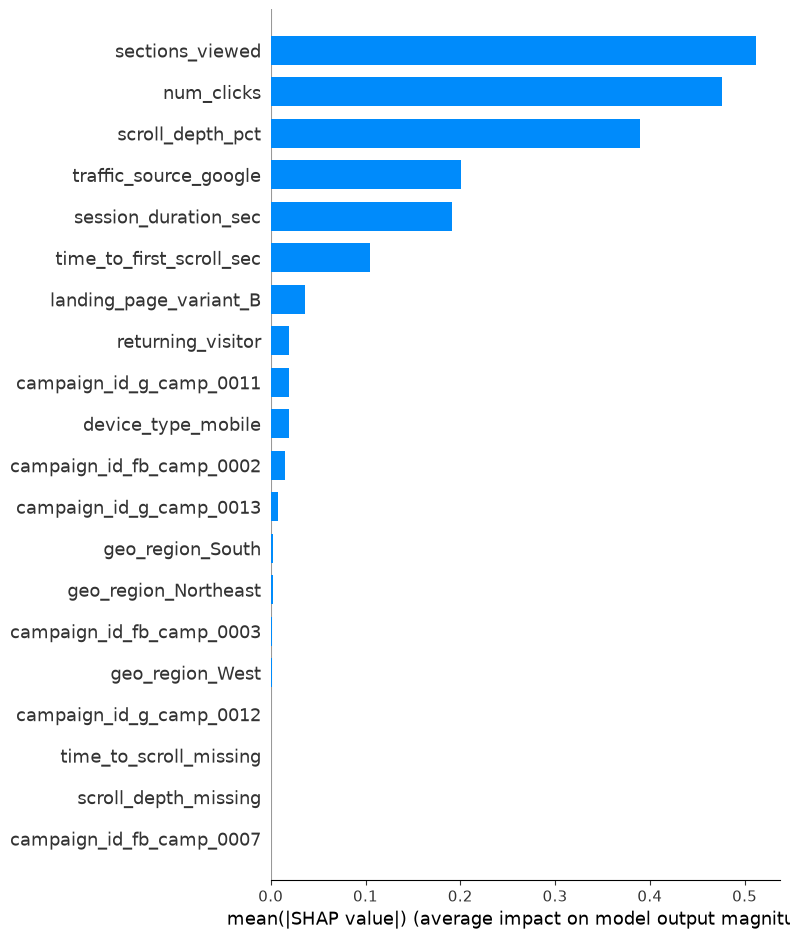

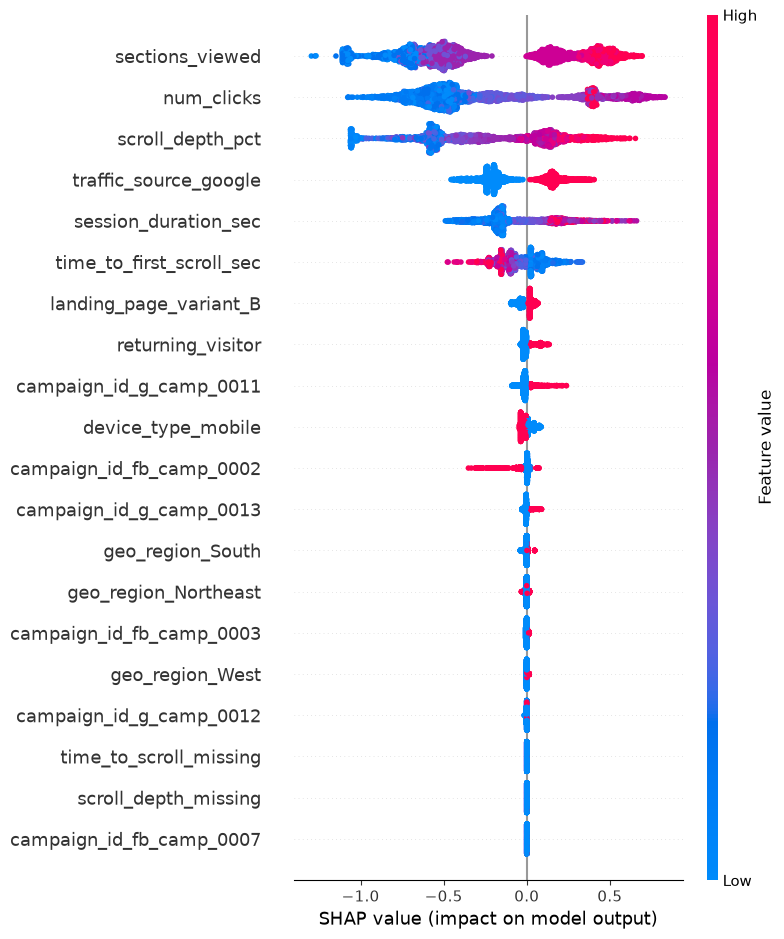

In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')
shap.summary_plot(shap_values, X_test)    

In [19]:
results = pd.DataFrame({'y_true': y_test.values, 'y_proba': y_pred_proba})
results = results.sort_values('y_proba', ascending=False).reset_index(drop=True)
results['decile'] = pd.qcut(results.index, 10, labels=False)

lift_table = results.groupby('decile').agg(
    n=('y_true', 'size'),
    conversions=('y_true', 'sum'),
    conversion_rate=('y_true', 'mean')
).reset_index()
lift_table['lift'] = lift_table['conversion_rate'] / y_test.mean()
print(lift_table)

   decile    n  conversions  conversion_rate      lift
0       0  401           97         0.241895  5.508615
1       1  401           38         0.094763  2.158014
2       2  401           19         0.047382  1.079007
3       3  400           11         0.027500  0.626250
4       4  401            6         0.014963  0.340739
5       5  401            2         0.004988  0.113580
6       6  400            1         0.002500  0.056932
7       7  401            1         0.002494  0.056790
8       8  401            1         0.002494  0.056790
9       9  401            0         0.000000  0.000000


In [20]:
results_sorted = results.sort_values('y_proba', ascending=False).reset_index(drop=True)

high_cutoff = results_sorted['y_proba'].quantile(0.80) 
medium_cutoff = results_sorted['y_proba'].quantile(0.50) 

print(f"High-intent cutoff (score >= this): {high_cutoff:.4f}")
print(f"Medium-intent cutoff (score >= this): {medium_cutoff:.4f}")

df['intent_score'] = model.predict_proba(X)[:, 1]

df['intent_tier'] = pd.cut(
    df['intent_score'],
    bins=[-np.inf, medium_cutoff, high_cutoff, np.inf],
    labels=['Low', 'Medium', 'High']
)

print(df['intent_tier'].value_counts(normalize=True))
print(df.groupby('intent_tier')['converted'].mean())

High-intent cutoff (score >= this): 0.5190
Medium-intent cutoff (score >= this): 0.2001
intent_tier
Low       0.488573
Medium    0.309182
High      0.202246
Name: proportion, dtype: float64
intent_tier
Low       0.001226
Medium    0.023241
High      0.178633
Name: converted, dtype: float64


In [21]:
profile_cols = ['returning_visitor', 'session_duration_sec', 'scroll_depth_pct', 
                 'num_clicks', 'sections_viewed', 'time_to_first_scroll_sec']
df.groupby('intent_tier')[profile_cols].mean()

,returning_visitor,session_duration_sec,scroll_depth_pct,num_clicks,sections_viewed,time_to_first_scroll_sec
intent_tier,,,,,,
Low,0.154428,22.615831,21.104045,6.163313,1.631498,6.260060
Medium,0.205939,47.824241,47.334087,3.773564,3.592318,4.489012
High,0.214903,101.081224,68.144288,7.259067,5.270664,3.213486


In [22]:
results['intent_tier'] = results['decile'].map(
    lambda d: 'High' if d <= 1 else ('Medium' if d <= 4 else 'Low')
)

tier_summary = results.groupby('intent_tier').agg(
    n=('y_true', 'size'),
    conversions=('y_true', 'sum'),
    conversion_rate=('y_true', 'mean')
).reindex(['High', 'Medium', 'Low'])

tier_summary['pct_of_traffic'] = tier_summary['n'] / tier_summary['n'].sum()
tier_summary['pct_of_conversions'] = tier_summary['conversions'] / tier_summary['conversions'].sum()
tier_summary['lift'] = tier_summary['conversion_rate'] / y_test.mean()

print(tier_summary.round(4))

                n  conversions  conversion_rate  pct_of_traffic  \
intent_tier                                                       
High          802          135           0.1683          0.2001   
Medium       1202           36           0.0300          0.2999   
Low          2004            5           0.0025          0.5000   

             pct_of_conversions    lift  
intent_tier                              
High                     0.7670  3.8333  
Medium                   0.2045  0.6820  
Low                      0.0284  0.0568  


In [ ]:
# A/B Testing

In [23]:
ab = df.groupby('landing_page_variant_B').agg(
    n=('converted', 'size'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
)
print(ab)

                            n  conversions  conversion_rate
landing_page_variant_B                                     
False                    8820          400         0.045351
True                    11220          480         0.042781


In [24]:
counts = df.groupby('landing_page_variant_B')['converted'].sum().values
nobs = df.groupby('landing_page_variant_B')['converted'].count().values
z_stat, p_value = proportions_ztest(counts, nobs)
print(f"z = {z_stat:.3f}, p = {p_value:.4f}")

z = 0.882, p = 0.3780


In [25]:
pd.crosstab(df['landing_page_variant_B'], df['traffic_source_google'], normalize='index')

traffic_source_google,False,True
landing_page_variant_B,,
False,0.595692,0.404308
True,0.598396,0.401604


In [26]:
pd.crosstab(df['landing_page_variant_B'], df['device_type_mobile'], normalize='index')

device_type_mobile,False,True
landing_page_variant_B,,
False,0.579592,0.420408
True,0.204813,0.795187


In [27]:
df[df['converted']==1].groupby('landing_page_variant_B')['appointment_set'].mean()

landing_page_variant_B
False    0.220000
True     0.270833
Name: appointment_set, dtype: float64

In [33]:
within = df.groupby(['device_type_mobile', 'landing_page_variant_B'])['converted'].agg(['size', 'sum', 'mean'])
print(within)

                                           size  sum      mean
device_type_mobile landing_page_variant_B                     
False              False                   5112  349  0.068271
                   True                    2298  218  0.094865
True               False                   3708   51  0.013754
                   True                    8922  262  0.029366


In [32]:
for dev in [False, True]:
    sub = df[df['device_type_mobile'] == dev]
    counts = sub.groupby('landing_page_variant_B')['converted'].sum().values
    nobs = sub.groupby('landing_page_variant_B')['converted'].count().values
    z, p = proportions_ztest(counts, nobs)
    print(f"mobile={dev}: z={z:.3f}, p={p:.4f}")

mobile=False: z=-3.983, p=0.0001
mobile=True: z=-5.140, p=0.0000


In [29]:
leads = df[df['converted']==1]
counts = leads.groupby('landing_page_variant_B')['appointment_set'].sum().values
nobs = leads.groupby('landing_page_variant_B')['appointment_set'].count().values
z, p = proportions_ztest(counts, nobs)
print(f"z={z:.3f}, p={p:.4f}")

z=-1.739, p=0.0820


In [34]:
df['form_abandoned'] = ((df['form_started']==1) & (df['converted']==0)).astype(int)
print(df['form_abandoned'].sum())
df.groupby('form_abandoned')[['session_duration_sec','scroll_depth_pct','sections_viewed']].mean()

2720


,session_duration_sec,scroll_depth_pct,sections_viewed
form_abandoned,,,
0,42.954942,36.339850,2.805254
1,67.446029,53.931728,4.046691


In [35]:
pd.crosstab(df['form_abandoned'], df['intent_tier'], normalize='index')

intent_tier,Low,Medium,High
form_abandoned,,,
0,0.533430,0.296651,0.169919
1,0.202941,0.388971,0.408088


In [42]:
df['form_abandoned'].sum()

np.int64(2720)

In [ ]:
# Loading Model

In [ ]:
loaded_model = xgb.XGBClassifier()
loaded_model.load_model('intent_propensity_xgb.json')

In [46]:
# Lead Analysis

In [47]:
leads = df[df['converted']==1]

tier_quality = leads.groupby('intent_tier').agg(
    n_leads=('appointment_set', 'size'),
    appointments=('appointment_set', 'sum'),
    appointment_rate=('appointment_set', 'mean')
)
print(tier_quality)

             n_leads  appointments  appointment_rate
intent_tier                                         
Low               12           6.0          0.500000
Medium           144          58.0          0.402778
High             724         154.0          0.212707


In [48]:
tier_value = df.groupby('intent_tier').apply(
    lambda g: pd.Series({
        'sessions': len(g),
        'appointments': g['appointment_set'].sum(),
        'appts_per_1000_sessions': 1000 * g['appointment_set'].sum() / len(g)
    })
)
print(tier_value)

             sessions  appointments  appts_per_1000_sessions
intent_tier                                                 
Low            9791.0           6.0                 0.612808
Medium         6196.0          58.0                 9.360878
High           4053.0         154.0                37.996546


In [49]:
mh = leads[leads['intent_tier'].isin(['Medium','High'])]
counts = mh.groupby('intent_tier', observed=True)['appointment_set'].sum().values
nobs = mh.groupby('intent_tier', observed=True)['appointment_set'].count().values
z, p = proportions_ztest(counts, nobs)
print(f"z={z:.2f}, p={p:.5f}")

z=4.85, p=0.00000
